In [22]:
import pandas as pd
df=pd.read_csv("comedy_new.csv")
df

,Age,Exp,Rank,Nationality,GO
0,36,10,9,UK,NO
1,42,12,4,USA,NO
2,23,4,6,N,NO
3,52,4,4,USA,NO
4,43,21,8,USA,YES
5,44,14,5,UK,NO
6,66,3,7,N,YES
7,35,14,9,UK,YES
8,52,13,7,N,YES
9,35,5,9,N,YES


In [23]:
df.info

<bound method DataFrame.info of     Age  Exp  Rank Nationality   GO
0    36   10     9          UK   NO
1    42   12     4         USA   NO
2    23    4     6           N   NO
3    52    4     4         USA   NO
4    43   21     8         USA  YES
5    44   14     5          UK   NO
6    66    3     7           N  YES
7    35   14     9          UK  YES
8    52   13     7           N  YES
9    35    5     9           N  YES
10   24    3     5         USA   NO
11   18    3     7          UK  YES
12   45    9     9          UK  YES>

In [24]:
df.shape

(13, 5)

In [25]:
df.columns

Index(['Age', 'Exp', 'Rank', 'Nationality', 'GO'], dtype='object')

In [26]:
df.head

<bound method NDFrame.head of     Age  Exp  Rank Nationality   GO
0    36   10     9          UK   NO
1    42   12     4         USA   NO
2    23    4     6           N   NO
3    52    4     4         USA   NO
4    43   21     8         USA  YES
5    44   14     5          UK   NO
6    66    3     7           N  YES
7    35   14     9          UK  YES
8    52   13     7           N  YES
9    35    5     9           N  YES
10   24    3     5         USA   NO
11   18    3     7          UK  YES
12   45    9     9          UK  YES>

In [27]:
df['Nationality']=df['Nationality'].map({'UK':0,'USA':1,'N':2})

In [28]:
df

,Age,Exp,Rank,Nationality,GO
0,36,10,9,0,NO
1,42,12,4,1,NO
2,23,4,6,2,NO
3,52,4,4,1,NO
4,43,21,8,1,YES
5,44,14,5,0,NO
6,66,3,7,2,YES
7,35,14,9,0,YES
8,52,13,7,2,YES
9,35,5,9,2,YES


In [31]:
d2={'NO':0,'YES':1}
df['GO']=df['GO'].map(d2)

In [32]:
df

,Age,Exp,Rank,Nationality,GO
0,36,10,9,0,0
1,42,12,4,1,0
2,23,4,6,2,0
3,52,4,4,1,0
4,43,21,8,1,1
5,44,14,5,0,0
6,66,3,7,2,1
7,35,14,9,0,1
8,52,13,7,2,1
9,35,5,9,2,1


In [35]:
x=df.iloc[:,:-1]
x

,Age,Exp,Rank,Nationality
0,36,10,9,0
1,42,12,4,1
2,23,4,6,2
3,52,4,4,1
4,43,21,8,1
5,44,14,5,0
6,66,3,7,2
7,35,14,9,0
8,52,13,7,2
9,35,5,9,2


In [36]:
y=df['GO']
y

0     0
1     0
2     0
3     0
4     1
5     0
6     1
7     1
8     1
9     1
10    0
11    1
12    1
Name: GO, dtype: int64

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((10, 4), (3, 4), (10,), (3,))

In [39]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred=model.predict(x_test)

In [43]:
y_pred

array([1, 1, 1])

In [44]:
y_test

11    1
9     1
0     0
Name: GO, dtype: int64

In [45]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.6666666666666666


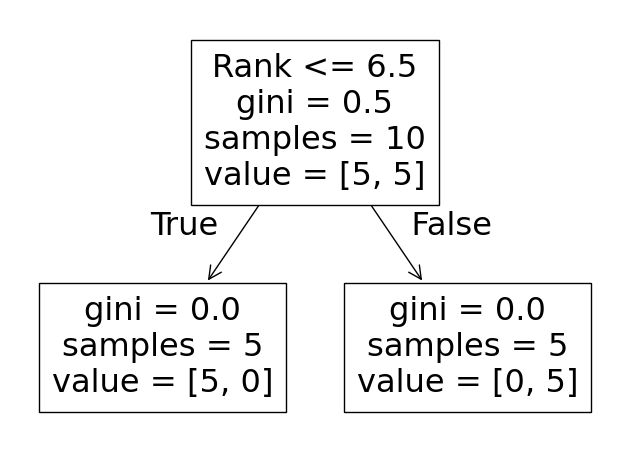

In [47]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(model,feature_names=['Age','Exp','Rank','Nationality'])
plt.tight_layout()
plt.show()